In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
import os
os.listdir('.')

['venv',
 'EDA.ipynb',
 '.ipynb_checkpoints',
 'README.md',
 '.git',
 'dataset',
 '.gitignore',
 'preprocess.py']

# Exploratory Data Analysis

## Structure Check

### (1) Raw Dataset Overview

In [3]:
df = pd.read_csv('dataset/raw.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


### (2) Columns Indices

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### (3) Number of row and column

In [5]:
df.shape

(303, 14)

### (4) Check for NULL data and data types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Target Variable distribution
0: no disease
1: diseased

In [7]:
df['target'].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

## Feature Distribution

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


### (1) Histogram

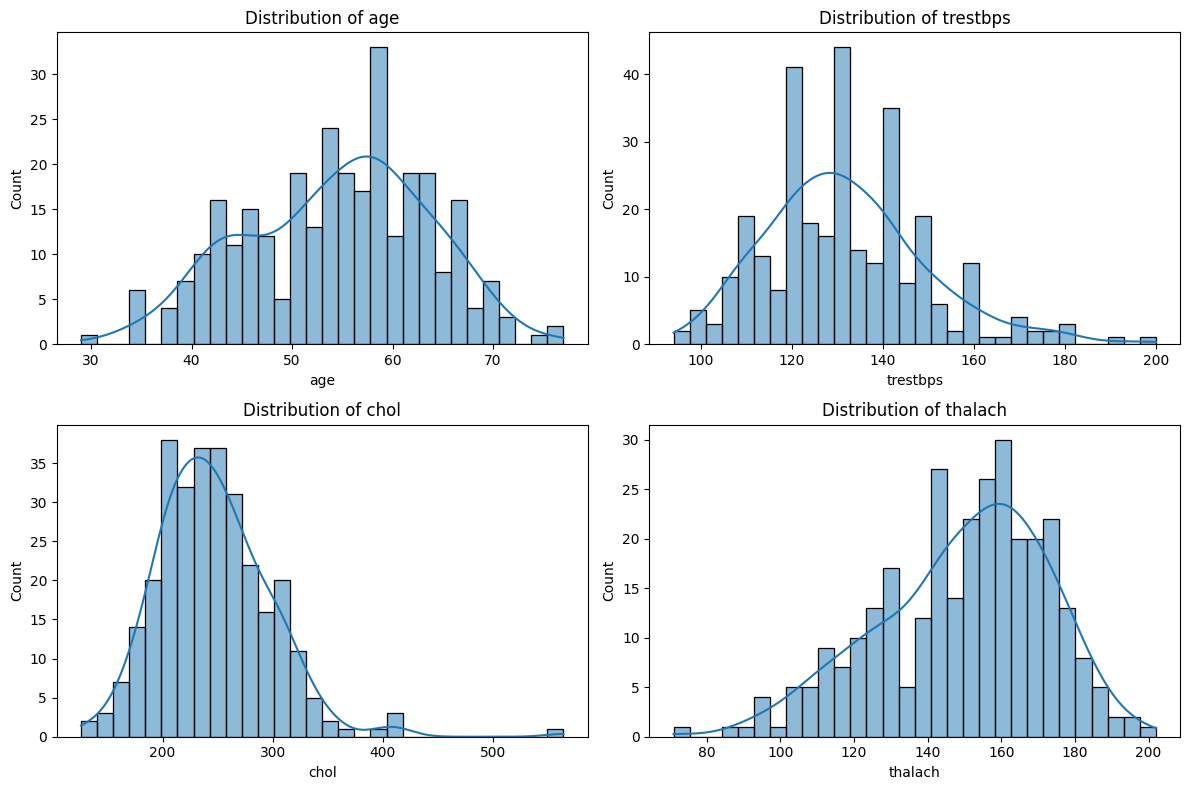

In [9]:
continuous_cols = ["age", "trestbps", "chol", "thalach"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### (2) Boxplots for Outlier detection

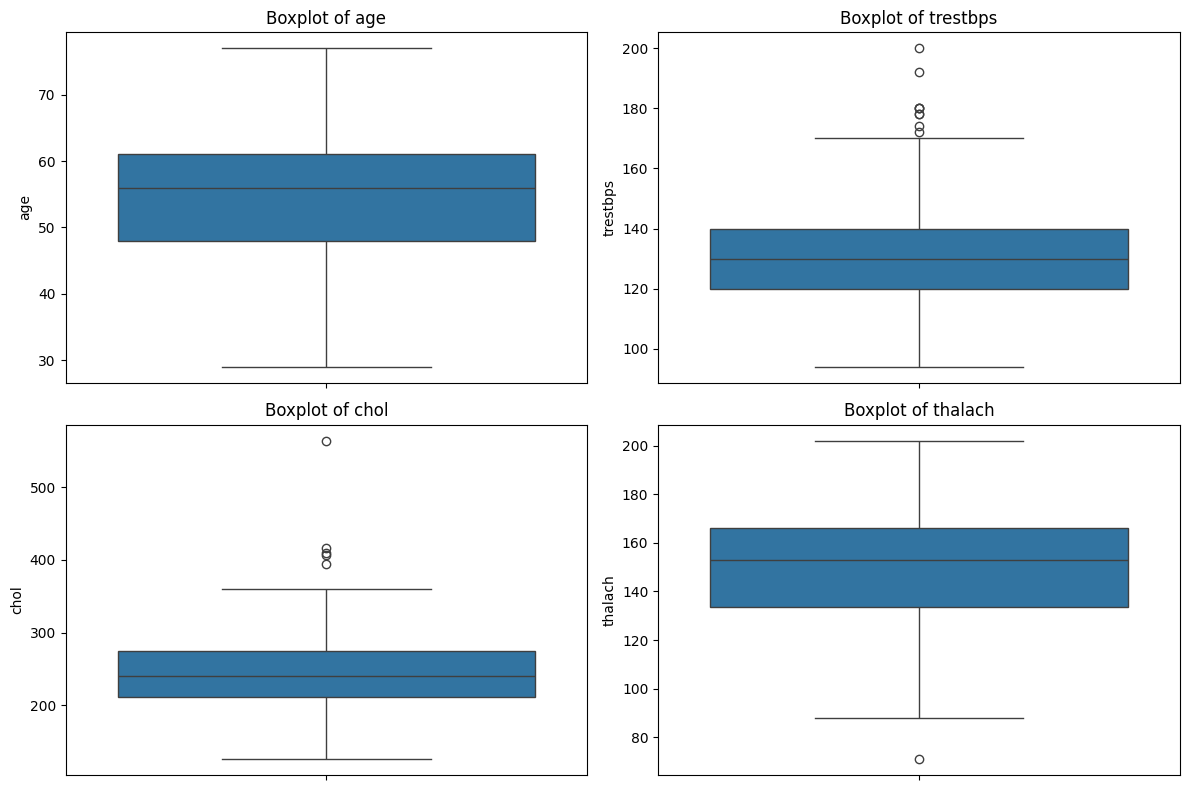

In [10]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

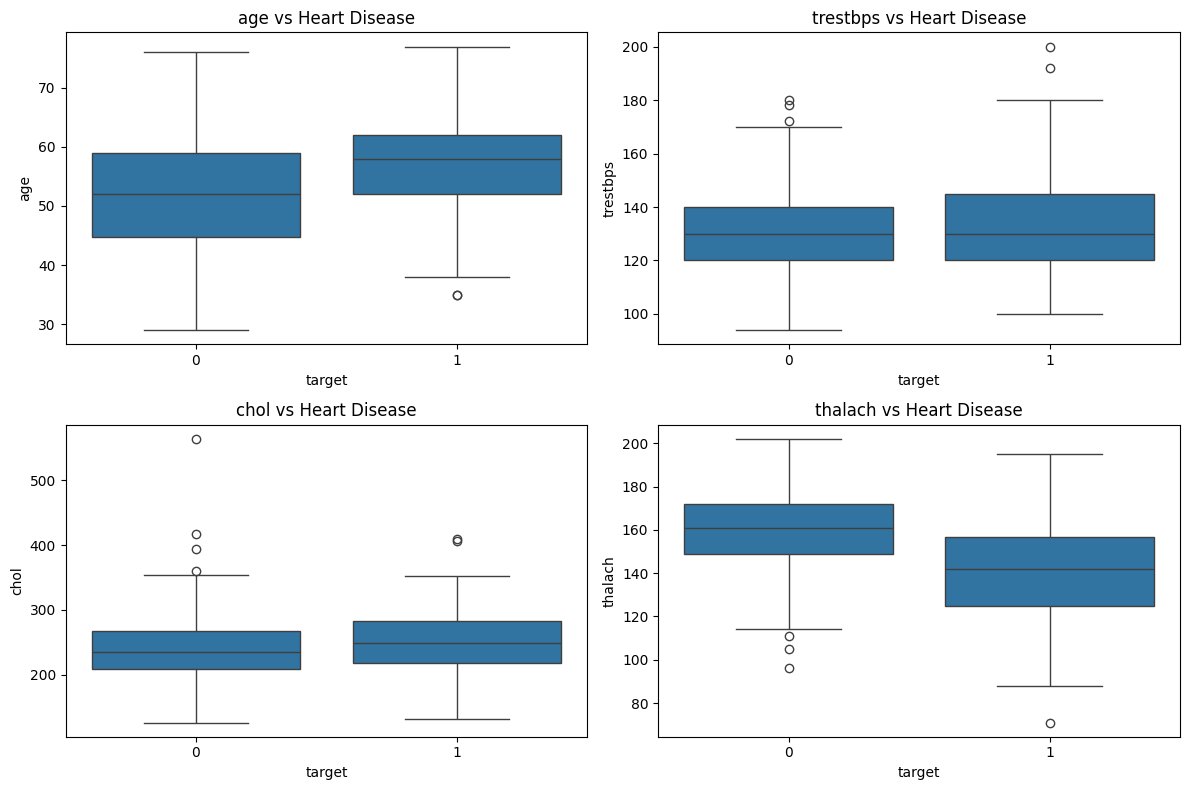

In [11]:
target_col = "target"  # usually 0/1

plt.figure(figsize=(12, 8))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(f"{col} vs Heart Disease")

plt.tight_layout()
plt.show()

## Relationship

### (1) Correlation Heatmap

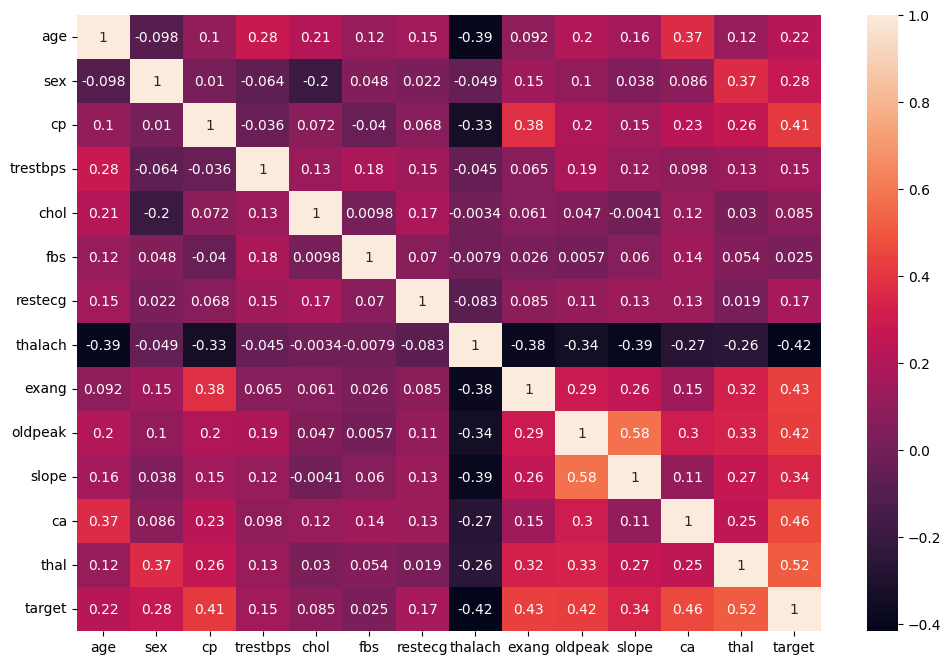

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr() , annot=True)
plt.show()

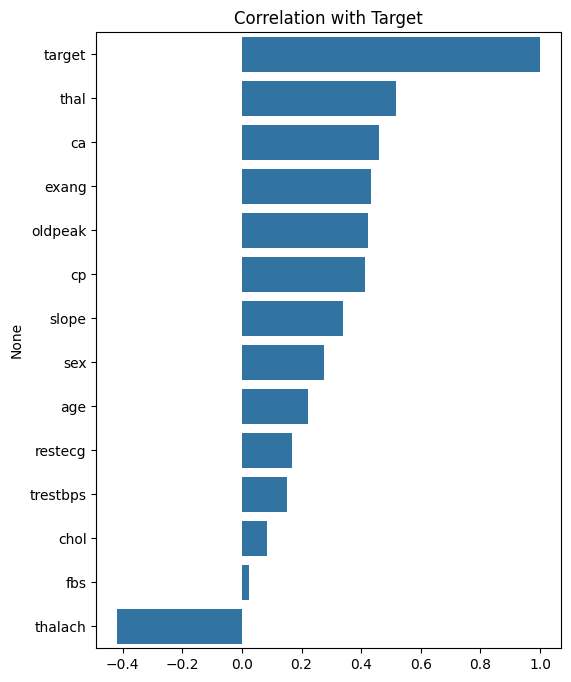

In [13]:
plt.figure(figsize=(6, 8))

target_corr = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)

sns.barplot(x=target_corr.values, y=target_corr.index)

plt.title("Correlation with Target")
plt.show()

### (2)Groupby Means

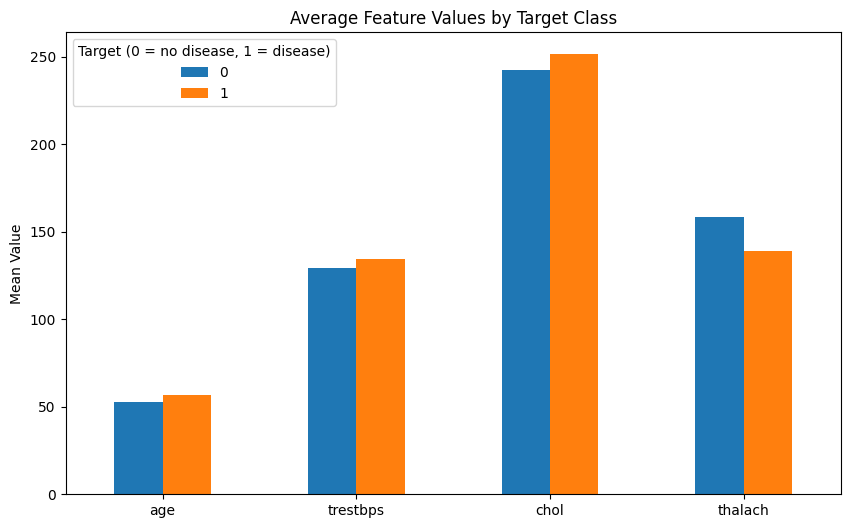

In [14]:
numeric_features = ["age", "trestbps", "chol", "thalach"]

group_means = df.groupby(target_col)[numeric_features].mean()
group_means.T.plot(kind="bar", figsize=(10, 6))

plt.title("Average Feature Values by Target Class")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Target (0 = no disease, 1 = disease)")
plt.show()

### (3)Categorical Feature vs Target

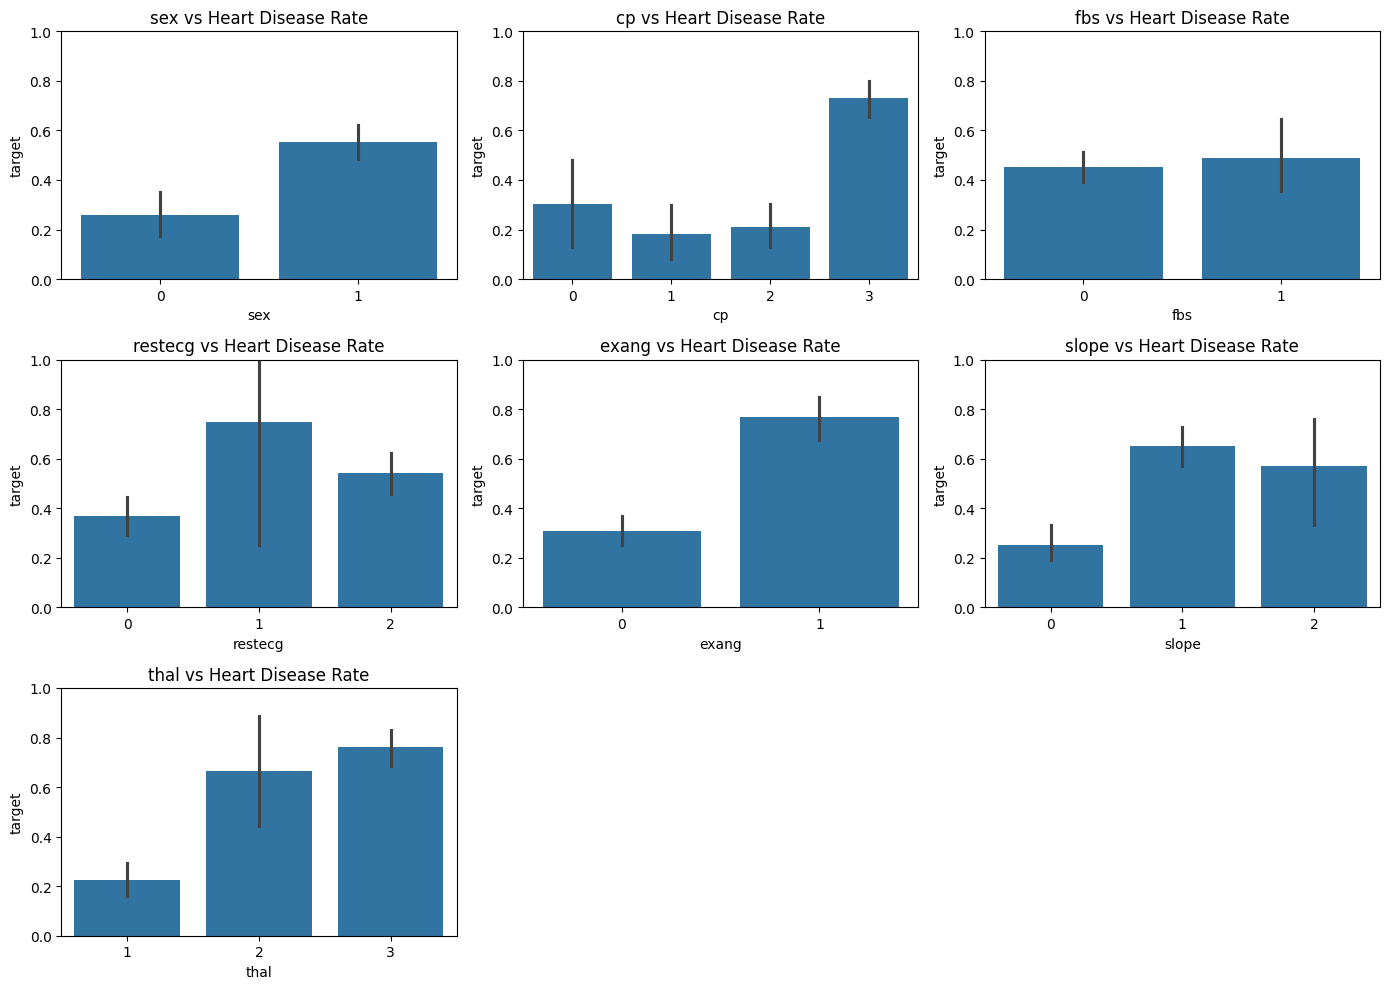

In [15]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    
    sns.barplot(
        x=col,
        y=target_col,
        data=df,
        estimator=lambda x: sum(x) / len(x)
    )
    
    plt.title(f"{col} vs Heart Disease Rate")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Feature Check

## Feature Dictionary

Source: [UCI Heart Disease — Cleveland subset](https://archive.ics.uci.edu/dataset/45/heart+disease)

| Feature | Type | Description |
|---|---|---|
| age | continuous | Age (years) |
| sex | categorical | 0 = female, 1 = male |
| cp | categorical | Chest pain: 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic |
| trestbps | continuous | Resting blood pressure at admission (mm Hg) |
| chol | continuous | Serum cholesterol (mg/dl) |
| fbs | categorical | Fasting blood sugar: 0 = ≤120 mg/dl, 1 = >120 mg/dl |
| restecg | categorical | Resting ECG: 0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy (Estes' criteria) |
| thalach | continuous | Maximum heart rate achieved (bpm) |
| exang | categorical | Exercise-induced angina: 0 = no, 1 = yes |
| oldpeak | continuous | ST depression induced by exercise relative to rest |
| slope | categorical | Slope of peak exercise ST segment: 0 = upsloping, 1 = flat, 2 = downsloping |
| ca | categorical | Number of major vessels colored by fluoroscopy (0–3) |
| thal | categorical | Thalassemia: 1 = normal, 2 = fixed defect, 3 = reversible defect |
| target | target | 0 = no disease, 1 = disease |

In [16]:
# Cleveland subset: 303 samples, no missing values
# (Other UCI sub-databases — Hungary, Switzerland, VA Long Beach — contain missing values)

continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']  # oldpeak was missing in original
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']  # ca was missing

feature_info = {
    'age':      ('continuous',  'Age (years)'),
    'sex':      ('categorical', '0=female, 1=male'),
    'cp':       ('categorical', '0=typical angina, 1=atypical angina, 2=non-anginal pain, 3=asymptomatic'),
    'trestbps': ('continuous',  'Resting blood pressure at admission (mm Hg)'),
    'chol':     ('continuous',  'Serum cholesterol (mg/dl)'),
    'fbs':      ('categorical', '0=fasting glucose ≤120 mg/dl, 1=>120 mg/dl'),
    'restecg':  ('categorical', '0=normal, 1=ST-T wave abnormality, 2=left ventricular hypertrophy (Estes)'),
    'thalach':  ('continuous',  'Maximum heart rate achieved (bpm)'),
    'exang':    ('categorical', '0=no exercise-induced angina, 1=yes'),
    'oldpeak':  ('continuous',  'ST depression induced by exercise relative to rest'),
    'slope':    ('categorical', '0=upsloping, 1=flat, 2=downsloping'),
    'ca':       ('categorical', 'Number of major vessels colored by fluoroscopy (0–3)'),
    'thal':     ('categorical', '1=normal, 2=fixed defect, 3=reversible defect'),
    'target':   ('target',      '0=no disease, 1=disease'),
}

print(f'{'Feature':<10} {'Type':<12} Description')
print('-' * 80)
for feat, (ftype, desc) in feature_info.items():
    print(f'{feat:<10} {ftype:<12} {desc}')

Feature    Type         Description
--------------------------------------------------------------------------------
age        continuous   Age (years)
sex        categorical  0=female, 1=male
cp         categorical  0=typical angina, 1=atypical angina, 2=non-anginal pain, 3=asymptomatic
trestbps   continuous   Resting blood pressure at admission (mm Hg)
chol       continuous   Serum cholesterol (mg/dl)
fbs        categorical  0=fasting glucose ≤120 mg/dl, 1=>120 mg/dl
restecg    categorical  0=normal, 1=ST-T wave abnormality, 2=left ventricular hypertrophy (Estes)
thalach    continuous   Maximum heart rate achieved (bpm)
exang      categorical  0=no exercise-induced angina, 1=yes
oldpeak    continuous   ST depression induced by exercise relative to rest
slope      categorical  0=upsloping, 1=flat, 2=downsloping
ca         categorical  Number of major vessels colored by fluoroscopy (0–3)
thal       categorical  1=normal, 2=fixed defect, 3=reversible defect
target     target       0=no

# Processed Data EDA
Analysis of the three preprocessed datasets (KNN, Logistic Regression, SVM).
Tree-based algorithms (Random Forest, Decision Tree) use the raw data unchanged and are skipped.

In [17]:
raw = pd.read_csv('dataset/raw.csv')

processed = {
    'KNN':                 pd.read_csv('dataset/processed_knn.csv'),
    'Logistic Regression': pd.read_csv('dataset/processed_logistic_regression.csv'),
    'SVM':                 pd.read_csv('dataset/processed_svm.csv'),
}

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
target_col = 'target'

## Feature Schema After Preprocessing

In [18]:
for name, df in processed.items():
    ohe_cols = [c for c in df.columns if '_' in c and c != target_col]
    print(f'{name}')
    print(f'  shape      : {df.shape}')
    print(f'  OHE cols   : {len(ohe_cols)} ({ohe_cols[:4]} ...)')
    print(f'  dtypes     : {dict(df.dtypes.value_counts())}')
    print()

KNN
  shape      : (303, 29)
  OHE cols   : 23 (['sex_0', 'sex_1', 'cp_0', 'cp_1'] ...)
  dtypes     : {dtype('bool'): np.int64(23), dtype('float64'): np.int64(5), dtype('int64'): np.int64(1)}

Logistic Regression
  shape      : (303, 29)
  OHE cols   : 23 (['sex_0', 'sex_1', 'cp_0', 'cp_1'] ...)
  dtypes     : {dtype('bool'): np.int64(23), dtype('float64'): np.int64(5), dtype('int64'): np.int64(1)}

SVM
  shape      : (303, 29)
  OHE cols   : 23 (['sex_0', 'sex_1', 'cp_0', 'cp_1'] ...)
  dtypes     : {dtype('bool'): np.int64(23), dtype('float64'): np.int64(5), dtype('int64'): np.int64(1)}



## Scaled Continuous Feature Distributions
After `StandardScaler`: each continuous feature should have mean ≈ 0 and std ≈ 1.

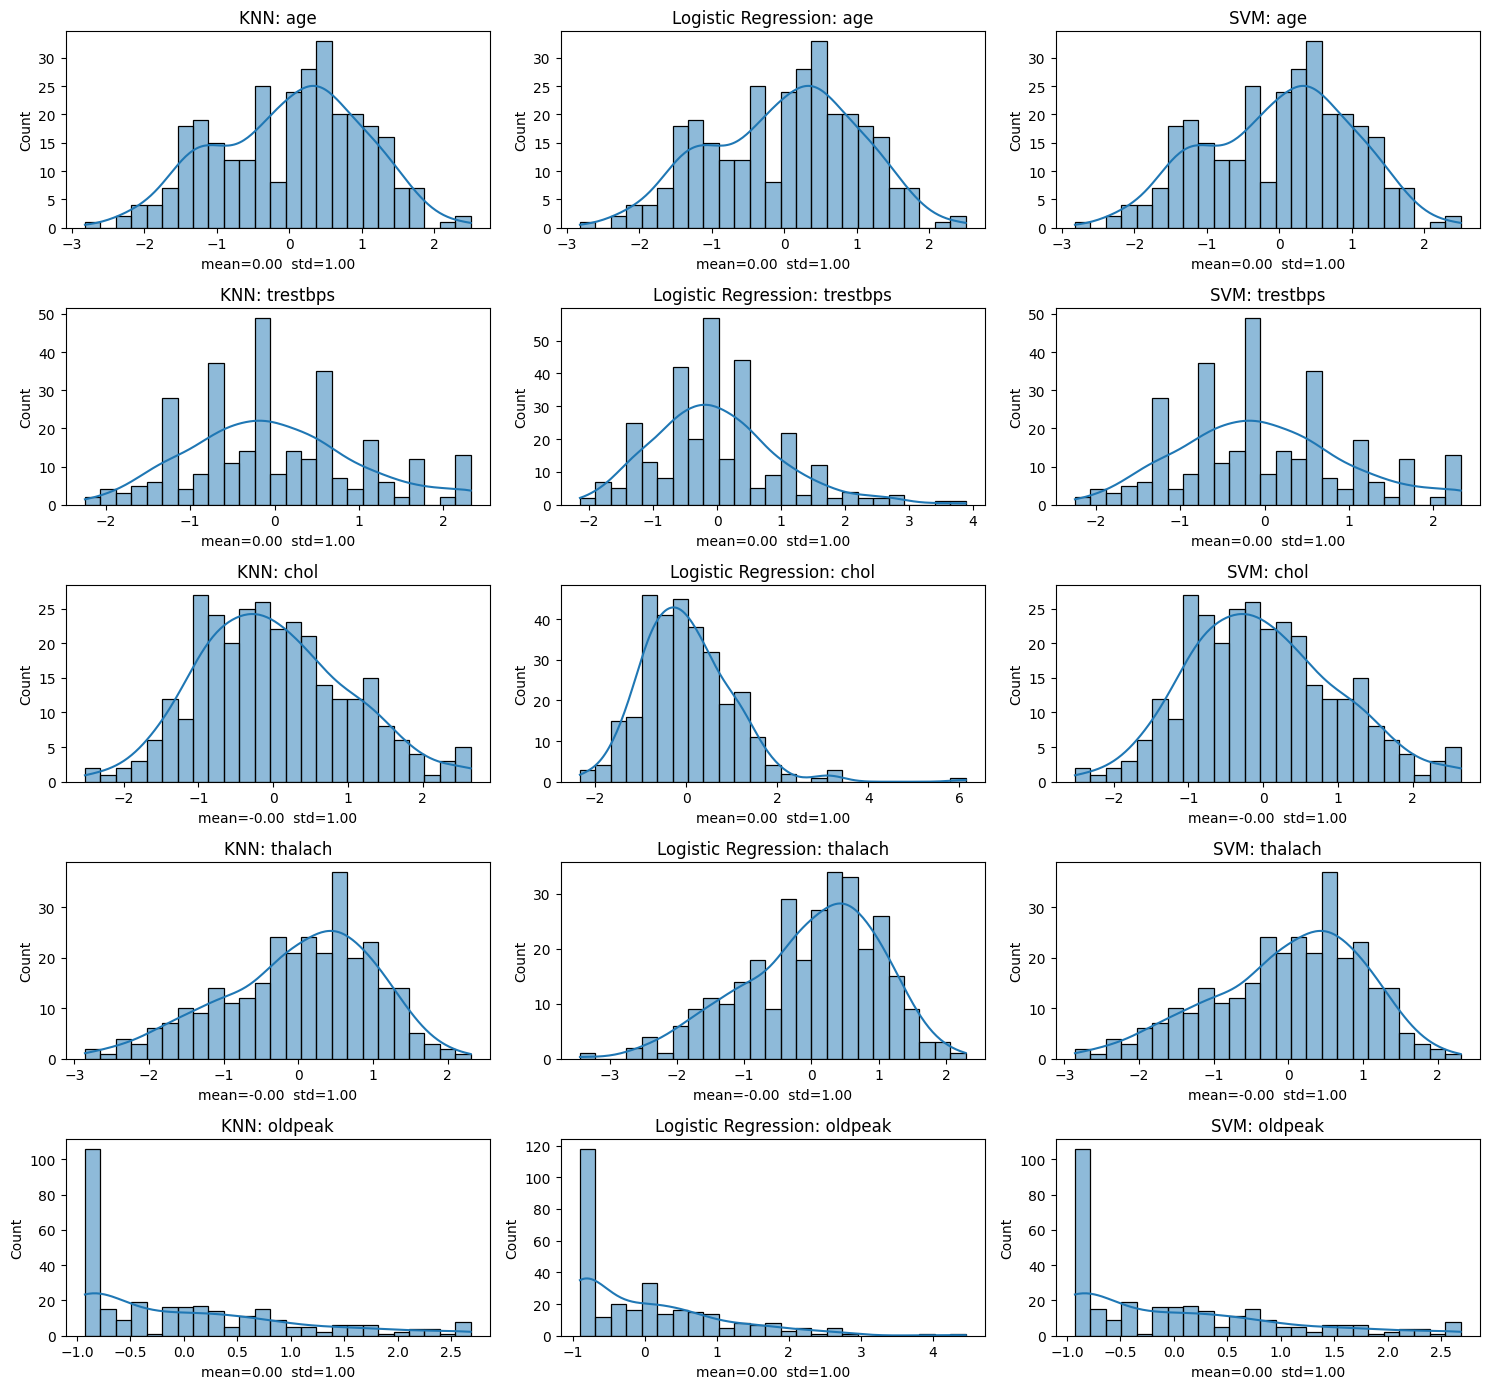

In [23]:
fig, axes = plt.subplots(len(continuous_cols), 3, figsize=(15, 14))
names = list(processed.keys())

for row, col in enumerate(continuous_cols):
    for col_idx, (name, df) in enumerate(processed.items()):
        ax = axes[row][col_idx]
        sns.histplot(df[col], kde=True, bins=25, ax=ax)
        ax.set_title(f'{name}: {col}')
        ax.set_xlabel(f'mean={df[col].mean():.2f}  std={df[col].std():.2f}')

plt.tight_layout()
plt.show()

## Outlier Check: Raw vs IQR-Capped (KNN & SVM)
KNN and SVM both apply IQR capping before scaling. This compares the continuous feature ranges before and after.

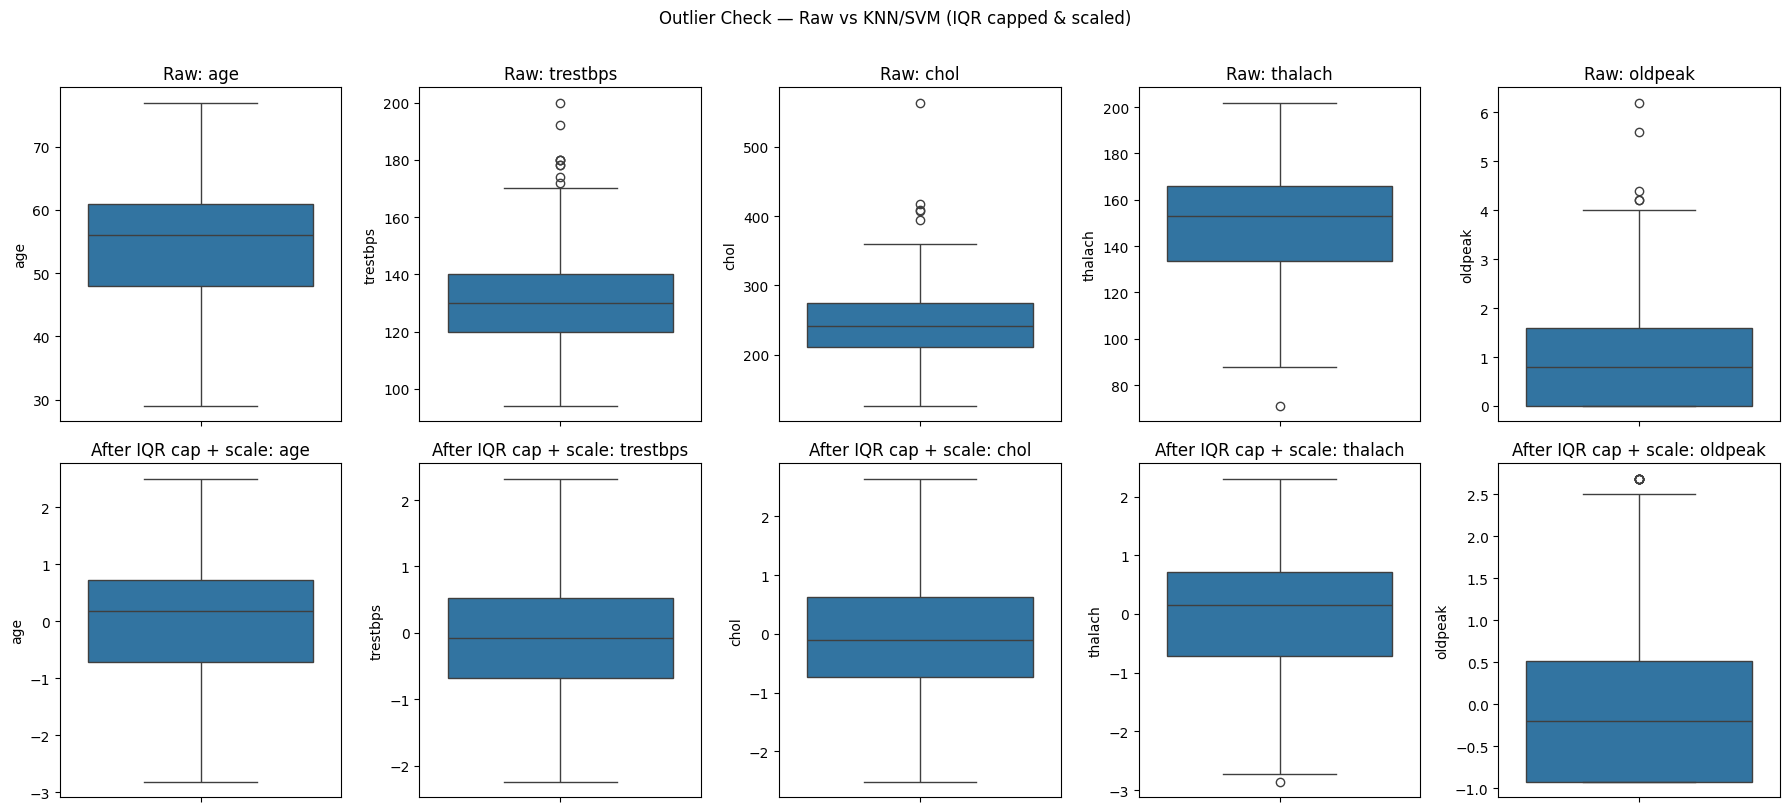

In [20]:
fig, axes = plt.subplots(2, len(continuous_cols), figsize=(18, 8))

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=raw[col], ax=axes[0][i])
    axes[0][i].set_title(f'Raw: {col}')

    # KNN and SVM are identical pre-scale; use KNN
    sns.boxplot(y=processed['KNN'][col], ax=axes[1][i])
    axes[1][i].set_title(f'After IQR cap + scale: {col}')

plt.suptitle('Outlier Check — Raw vs KNN/SVM (IQR capped & scaled)', y=1.01)
plt.tight_layout()
plt.show()

## Correlation with Target

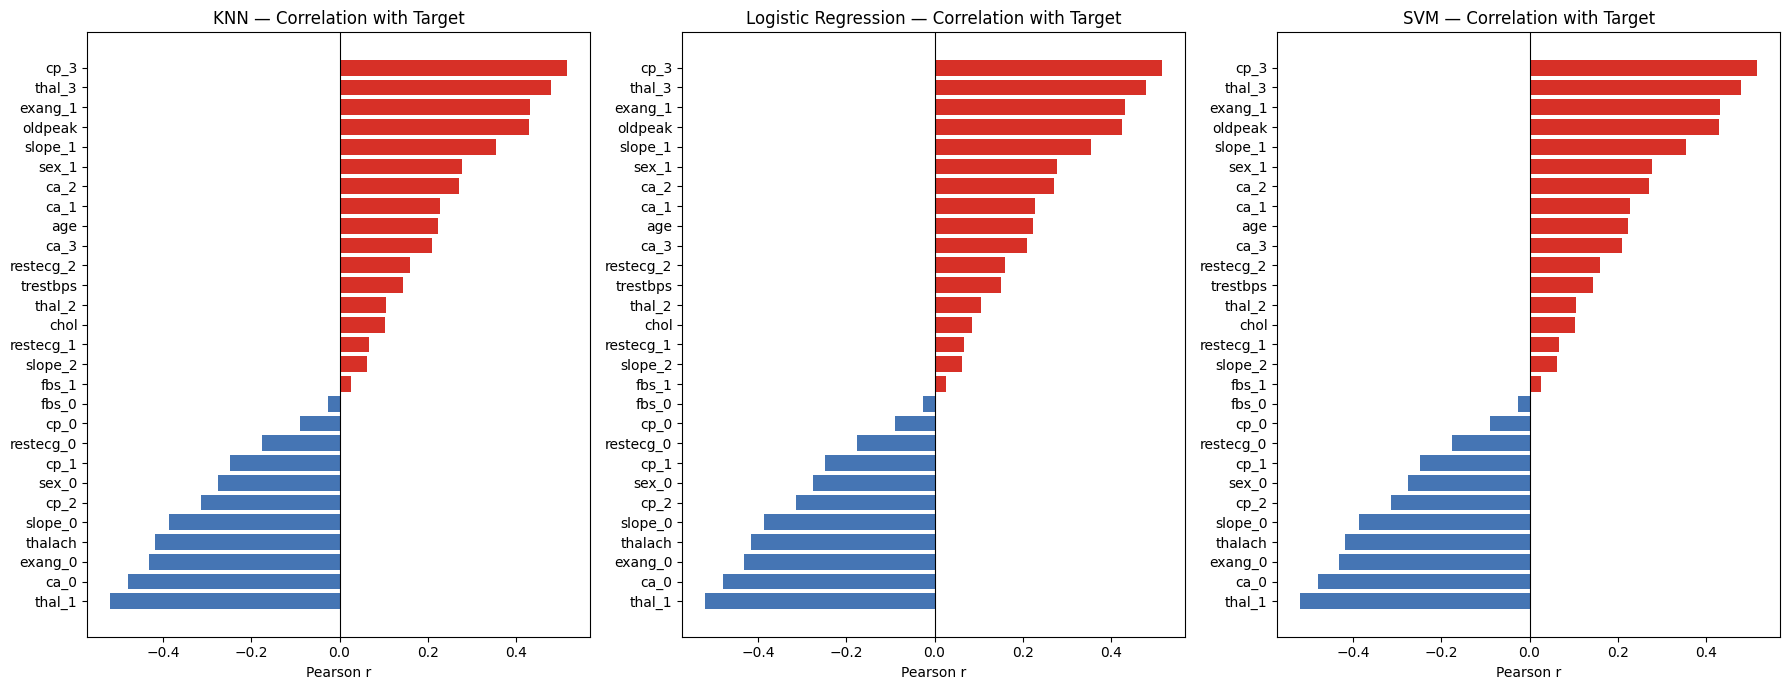

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (name, df) in zip(axes, processed.items()):
    corr = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values()
    colors = ['#d73027' if v > 0 else '#4575b4' for v in corr.values]
    ax.barh(corr.index, corr.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} — Correlation with Target')
    ax.set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

## Correlation Heatmap (Continuous Features)

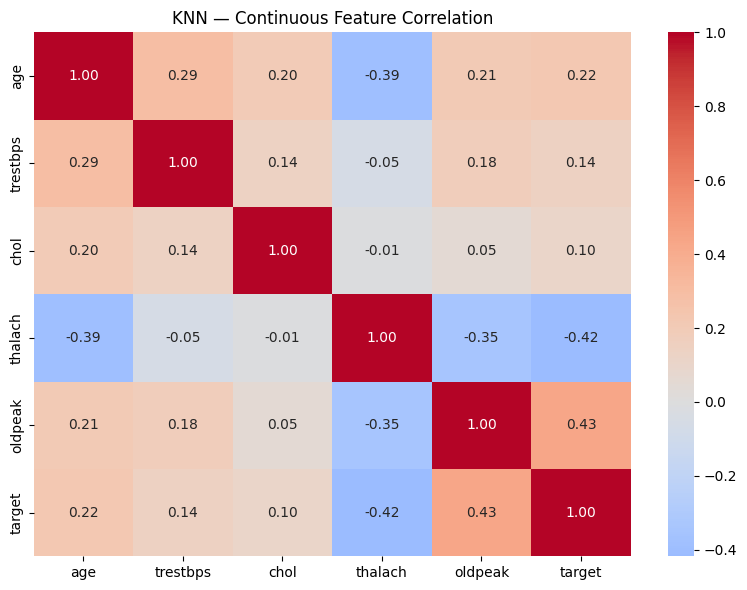

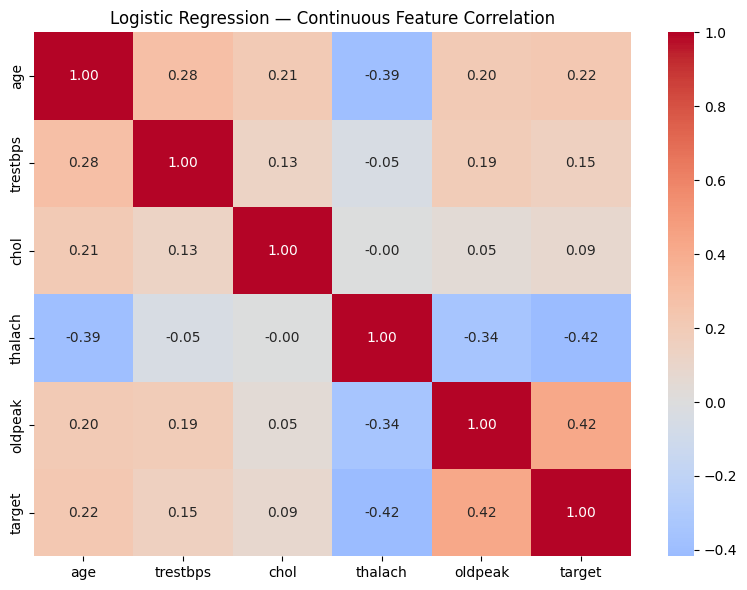

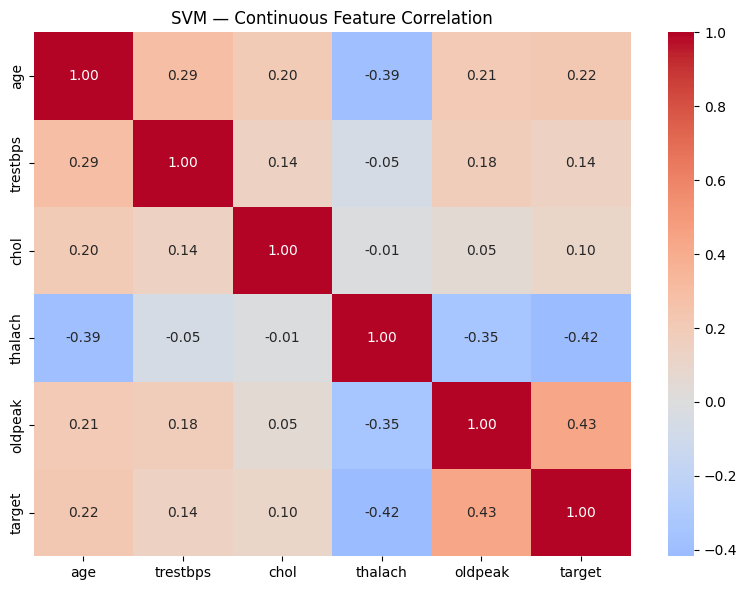

In [22]:
for name, df in processed.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        df[continuous_cols + [target_col]].corr(),
        annot=True, fmt='.2f', cmap='coolwarm', center=0
    )
    plt.title(f'{name} — Continuous Feature Correlation')
    plt.tight_layout()
    plt.show()